# Topic 1 — Logistic Regression vs Naive Bayes

**Q1:** Breast Cancer Wisconsin (binary classification)
**Q2:** Wine Quality (multiclass classification)

Put the CSV files in the same folder as this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

Matplotlib is building the font cache; this may take a moment.


---
## Question 1 — Breast Cancer Wisconsin

### Step 1: Load and inspect the dataset

In [2]:
def load_cancer(path="datasets/breast-cancer-wisconsin.csv"):
    df = pd.read_csv(path)
    df = df.replace("?", np.nan)      # missing values are stored as '?'
    df = df.drop(columns=["id"])      # id is not a feature
    return df.astype(float)

df = load_cancer()

print("Shape           :", df.shape)
print("Columns         :", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nTarget counts (2 = benign, 4 = malignant):\n", df["class"].value_counts())
df.head()

Shape           : (699, 10)
Columns         : ['clump_thickness', 'size_uniformity', 'shape_uniformity', 'marginal_adhesion', 'epithelial_size', 'bare_nucleoli', 'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

Data types:
 clump_thickness      float64
size_uniformity      float64
shape_uniformity     float64
marginal_adhesion    float64
epithelial_size      float64
bare_nucleoli        float64
bland_chromatin      float64
normal_nucleoli      float64
mitoses              float64
class                float64
dtype: object

Missing values:
 clump_thickness       0
size_uniformity       0
shape_uniformity      0
marginal_adhesion     0
epithelial_size       0
bare_nucleoli        16
bland_chromatin       0
normal_nucleoli       0
mitoses               0
class                 0
dtype: int64

Target counts (2 = benign, 4 = malignant):
 class
2.0    458
4.0    241
Name: count, dtype: int64


,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,2.0
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,2.0
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,2.0
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,2.0


### Step 2: Handle missing values

In [3]:
df = df.fillna(df.median())          # fill the 16 missing values with the column median
print("Missing values left:", df.isna().sum().sum())

Missing values left: 0


### Step 3: EDA — target distribution, two feature histograms, correlation heatmap

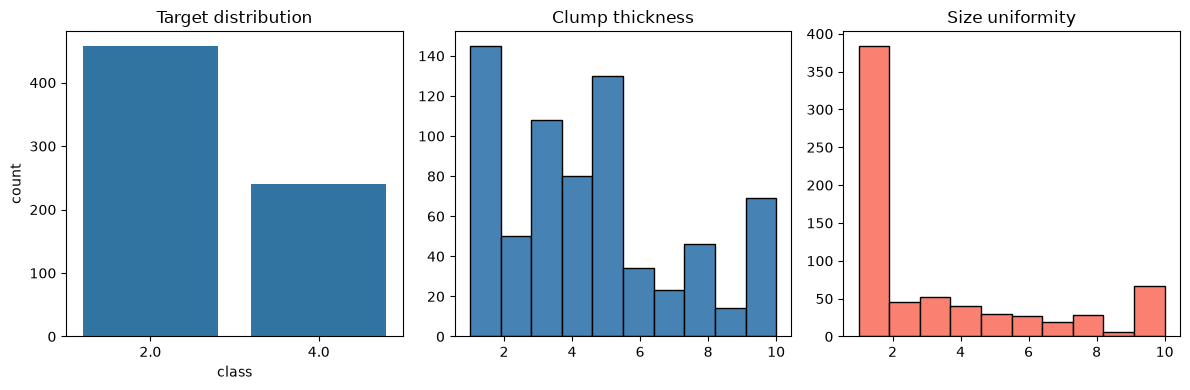

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="class", data=df)
plt.title("Target distribution")

plt.subplot(1, 3, 2)
plt.hist(df["clump_thickness"], bins=10, color="steelblue", edgecolor="black")
plt.title("Clump thickness")

plt.subplot(1, 3, 3)
plt.hist(df["size_uniformity"], bins=10, color="salmon", edgecolor="black")
plt.title("Size uniformity")

plt.tight_layout()
plt.show()

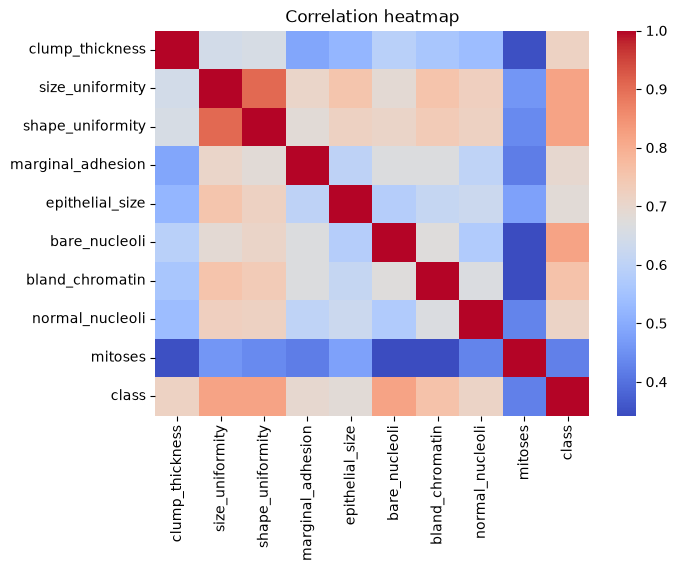

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation heatmap")
plt.show()

### Step 4: Features / target + train-test split + scaling

Logistic Regression works better on scaled data. Gaussian Naive Bayes does not need scaling
(it only estimates a mean and variance per feature), so it is trained on the raw features.

In [6]:
X = df.drop(columns=["class"])
y = (df["class"] == 4).astype(int)      # 1 = malignant, 0 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (559, 9)  Test: (140, 9)


### Step 5: Train both models and evaluate

In [7]:
def train_eval(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    scores = {"Model": name,
              "Accuracy": accuracy_score(yte, pred),
              "Precision": precision_score(yte, pred),
              "Recall": recall_score(yte, pred),
              "F1": f1_score(yte, pred)}
    return scores, confusion_matrix(yte, pred)


lr_scores, lr_cm = train_eval("Logistic Regression", LogisticRegression(max_iter=1000),
                              X_train_s, X_test_s, y_train, y_test)
nb_scores, nb_cm = train_eval("Naive Bayes (Gaussian)", GaussianNB(),
                              X_train, X_test, y_train, y_test)

results = pd.DataFrame([lr_scores, nb_scores]).round(4)
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9500,0.9362,0.9167,0.9263
1,Naive Bayes (Gaussian),0.9571,0.9200,0.9583,0.9388


### Step 6: Confusion matrices and metric comparison

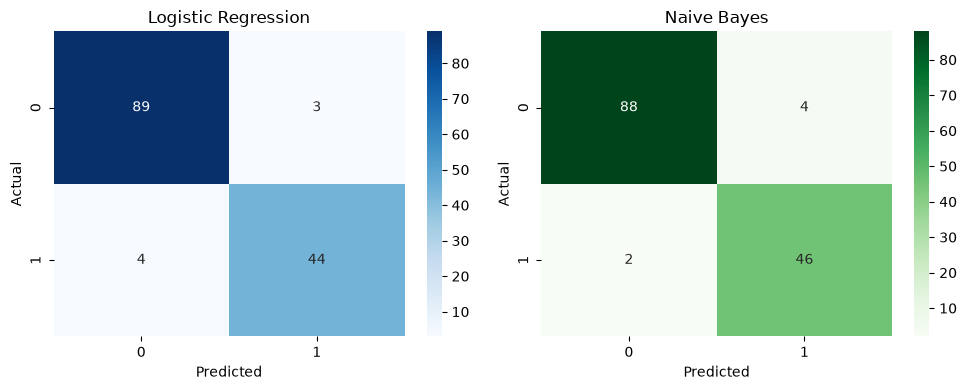

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Naive Bayes"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.tight_layout()
plt.show()

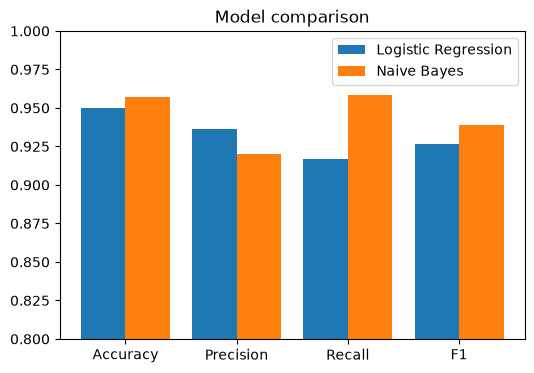

Better model (by F1-score): Naive Bayes (Gaussian)


In [9]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))
plt.bar(x - 0.2, results.loc[0, metrics], width=0.4, label="Logistic Regression")
plt.bar(x + 0.2, results.loc[1, metrics], width=0.4, label="Naive Bayes")
plt.xticks(x, metrics)
plt.ylim(0.8, 1.0)
plt.title("Model comparison")
plt.legend()
plt.show()

print("Better model (by F1-score):", results.loc[results["F1"].idxmax(), "Model"])

**Conclusion (Q1).** Both models classify the tumours well (~95% accuracy). Logistic Regression is
appropriate here because the target has exactly two classes and the features are numeric;
Naive Bayes is fast but assumes the features are independent, which is not true here
(the correlation heatmap shows strongly correlated features). Pick whichever model gives the
higher F1-score in your run and state that reason.

---
## Question 2 — Wine Quality (multiclass)

### Step 1: Load and inspect

In [10]:
wine = pd.read_csv("datasets/WineQT.csv").drop(columns=["Id"])

print("Shape          :", wine.shape)
print("Missing values :", wine.isna().sum().sum())
print("\nQuality scores:\n", wine["quality"].value_counts().sort_index())
wine.head()

Shape          : (1143, 12)
Missing values : 0

Quality scores:
 quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Step 2: Convert quality scores into 3 classes

Scores 3–8 are too few in some values, so group them:
`low (<=5)`, `medium (=6)`, `high (>=7)`. This keeps the problem **multiclass**.

In [11]:
def to_class(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

wine["quality_class"] = wine["quality"].apply(to_class)
print(wine["quality_class"].value_counts())

quality_class
low       522
medium    462
high      159
Name: count, dtype: int64


### Step 3: EDA

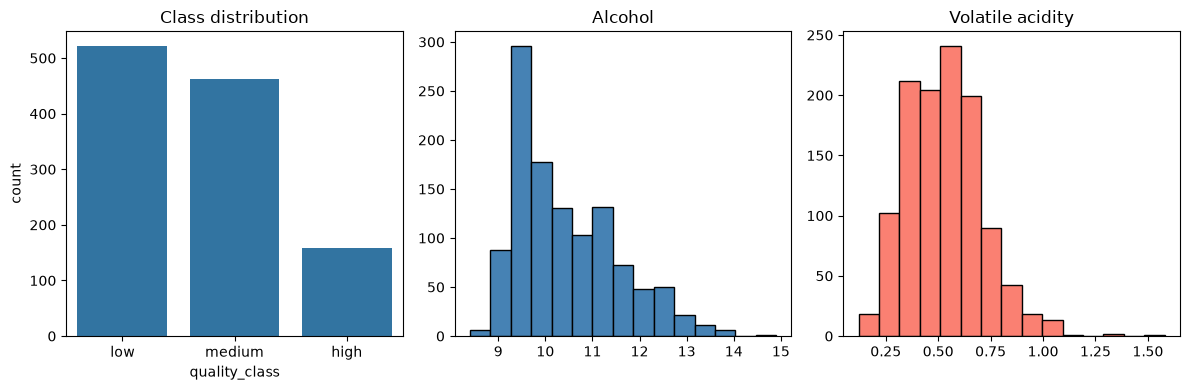

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="quality_class", data=wine, order=["low", "medium", "high"])
plt.title("Class distribution")

plt.subplot(1, 3, 2)
plt.hist(wine["alcohol"], bins=15, color="steelblue", edgecolor="black")
plt.title("Alcohol")

plt.subplot(1, 3, 3)
plt.hist(wine["volatile acidity"], bins=15, color="salmon", edgecolor="black")
plt.title("Volatile acidity")

plt.tight_layout()
plt.show()

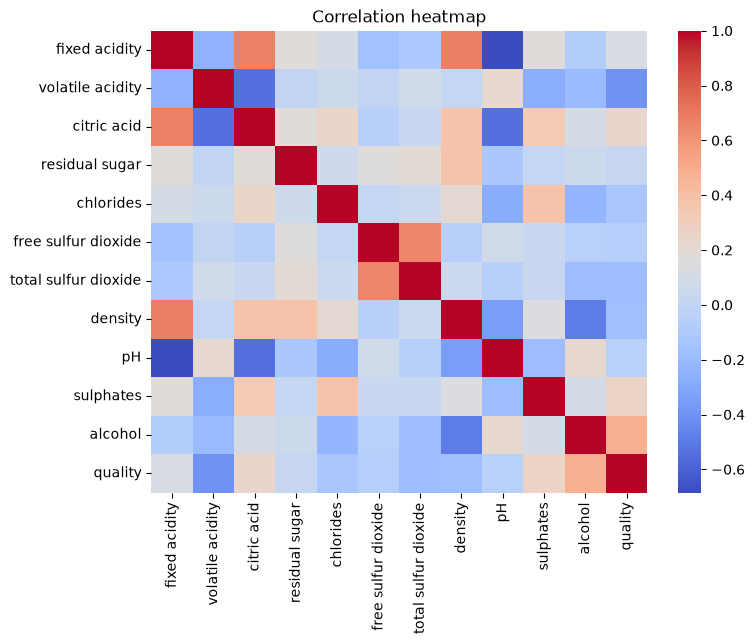

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(wine.drop(columns=["quality_class"]).corr(), cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

### Step 4: Split and scale

**Important:** Multinomial Naive Bayes cannot take negative values, so use `MinMaxScaler` (0–1)
for it, and `StandardScaler` for Logistic Regression.

In [14]:
X = wine.drop(columns=["quality", "quality_class"])
y = wine["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

std = StandardScaler().fit(X_train)
X_train_std, X_test_std = std.transform(X_train), std.transform(X_test)

mm = MinMaxScaler().fit(X_train)                 # non-negative values for MultinomialNB
X_train_mm, X_test_mm = mm.transform(X_train), mm.transform(X_test)

### Step 5: Train and evaluate (weighted averaging because it is multiclass)

In [15]:
labels = ["low", "medium", "high"]

def train_eval_multi(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    scores = {"Model": name,
              "Accuracy": accuracy_score(yte, pred),
              "Precision": precision_score(yte, pred, average="weighted", zero_division=0),
              "Recall": recall_score(yte, pred, average="weighted"),
              "F1": f1_score(yte, pred, average="weighted")}
    return scores, confusion_matrix(yte, pred, labels=labels)


lr_scores, lr_cm = train_eval_multi("Logistic Regression", LogisticRegression(max_iter=1000),
                                    X_train_std, X_test_std, y_train, y_test)
nb_scores, nb_cm = train_eval_multi("Multinomial NB", MultinomialNB(),
                                    X_train_mm, X_test_mm, y_train, y_test)

results = pd.DataFrame([lr_scores, nb_scores]).round(4)
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6376,0.6315,0.6376,0.6321
1,Multinomial NB,0.5546,0.4648,0.5546,0.4707


### Step 6: Confusion matrices and comparison

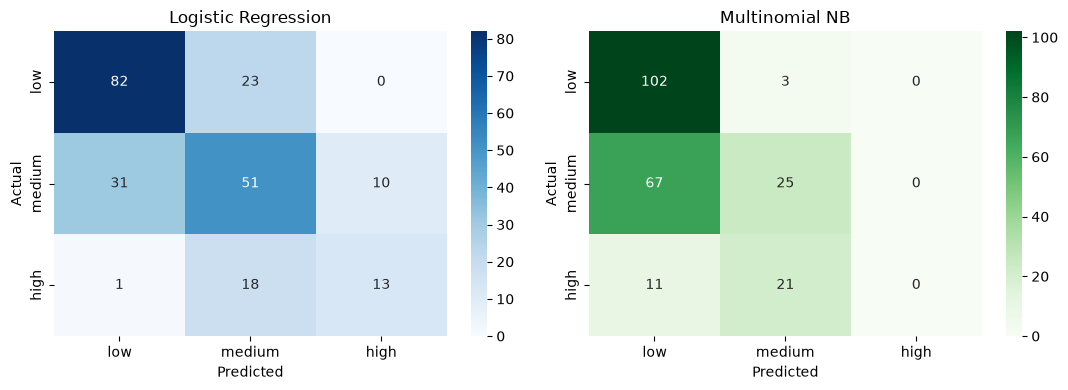

In [16]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Logistic Regression"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Multinomial NB"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.tight_layout()
plt.show()

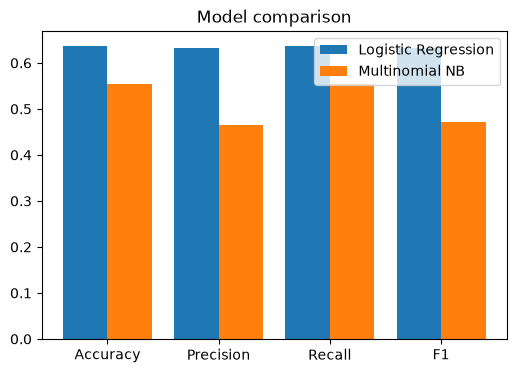

Better model: Logistic Regression


In [17]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))
plt.bar(x - 0.2, results.loc[0, metrics], width=0.4, label="Logistic Regression")
plt.bar(x + 0.2, results.loc[1, metrics], width=0.4, label="Multinomial NB")
plt.xticks(x, metrics)
plt.title("Model comparison")
plt.legend()
plt.show()

print("Better model:", results.loc[results["F1"].idxmax(), "Model"])

**Conclusion (Q2).** Logistic Regression clearly wins here (~0.63 vs ~0.55 accuracy).
Reasons to write in the exam:

1. Logistic Regression handles multiclass automatically with a softmax (multinomial) formulation.
2. Multinomial NB is designed for **count data** (like word counts), not continuous physicochemical
   measurements, so it is a poor fit for this dataset even after min-max scaling.
3. Both models struggle with the `high` class because it has far fewer samples (class imbalance).